In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from sklearn.utils import shuffle
from keras.layers import LSTM, GRU, Dropout, Dense, Input
from imblearn.over_sampling import RandomOverSampler
import random
import os

In [3]:
# =============================
# 1. Charger les données
# =============================
df = pd.read_csv("C:\\Users\\sarrj\\Documents\\Mes doc\\Doc\\Articles\\smart_manufacturing_data.csv", parse_dates=['timestamp'], index_col='timestamp')

# =============================
# 2. Appliquer les seuils ISO
# =============================
def iso_state(v):
    if pd.isna(v):
        return np.nan
    if v < 2.8:
        return 'OK'
    elif v < 7.1:
        return 'Attention'
    elif v < 11.2:
        return 'Alerte'
    else:
        return 'Critique'

df['State_ISO'] = df['vibration'].apply(iso_state)

# ===========================================
# 3. Définir la colonne cible : panne
# (Critique = panne, le reste = normal)
# ===========================================
df['panne'] = (df['State_ISO'] == 'Critique').astype(int)

# =============================
# 4. Normaliser les variables d'entrée
# =============================
features = ['pressure', 'temperature', 'vibration', 'humidity']
df[features] = df[features].astype(np.float32)


In [4]:
scaler = MinMaxScaler()

df[features] = scaler.fit_transform(df[features])
df.dropna(inplace=True)

In [5]:
# =============================
# 5. Créer les séquences temporelles
# =============================
def create_sequences(df, features, target='panne', time_steps=20, max_samples = None):
    X, y = [], []
    for i in range(max_samples - time_steps):
        X.append(df[features].iloc[i:i + time_steps].values)
        y.append(df[target].iloc[i + time_steps])
    return np.array(X), np.array(y)

time_steps = 5
X, y = create_sequences(df, features, target='panne', time_steps=5,max_samples=len(df))##, max_samples=15000)

#X, y = create_sequences(df, features, target='panne', time_steps=time_steps)

# 1. Aplatir X (nécessaire pour RandomOverSampler)
X_flat = X.reshape((X.shape[0], -1))
print(f"Avant RandomOverSampler : {np.bincount(y)}")

# 2. Appliquer RandomOverSampler
ros = RandomOverSampler(sampling_strategy=0.5, random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_flat, y)
print(f"Après RandomOverSampler : {np.bincount(y_resampled)}")

# 3. Reformater pour LSTM
X_resampled = X_resampled.reshape((X_resampled.shape[0], time_steps, len(features)))

# 4. Mélanger les données (pour casser l'ordre temporel global)
X_resampled, y_resampled = shuffle(X_resampled, y_resampled, random_state=42)

# =============================
# 8. Split Train/Test
# =============================
split = int(0.8 * len(X_resampled))
X_train, X_test = X_resampled[:split], X_resampled[split:]
y_train, y_test = y_resampled[:split], y_resampled[split:]

MemoryError: Unable to allocate 1.53 MiB for an array with shape (4, 100000) and data type float32

In [52]:
# =============================
# 7. Modèle 1 LSTM
# =============================
model = Sequential()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.add(LSTM(4, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))


# =============================
# 8. Entraînement
# =============================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                    epochs=20, batch_size=32, callbacks=[early_stop])

# =============================
# 9. Prédiction et Évaluation
# =============================
y_pred = (model.predict(X_test) > 0.7).astype(int)
print("\n📊 Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=["Pas de panne", "Panne"]))

C:\Users\sarrj\AppData\Local\anaconda3\envs\article_ucad\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6593 - loss: 0.6455 - val_accuracy: 0.6559 - val_loss: 0.6433
Epoch 2/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6693 - loss: 0.6364 - val_accuracy: 0.6559 - val_loss: 0.6427
Epoch 3/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6693 - loss: 0.6355 - val_accuracy: 0.6559 - val_loss: 0.6431
Epoch 4/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6693 - loss: 0.6349 - val_accuracy: 0.6559 - val_loss: 0.6427
Epoch 5/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6693 - loss: 0.6338 - val_accuracy: 0.6559 - val_loss: 0.6420
Epoch 6/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6693 - loss: 0.6327 - val_accuracy: 0.6559 - val_loss: 0.6412
Epoch 7/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6693 - loss: 0.6309 - val_accuracy: 0.6559 - val_loss: 0.6402
Epoch 8/20
560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6705 - loss: 0.6300 - val_accuracy: 0.

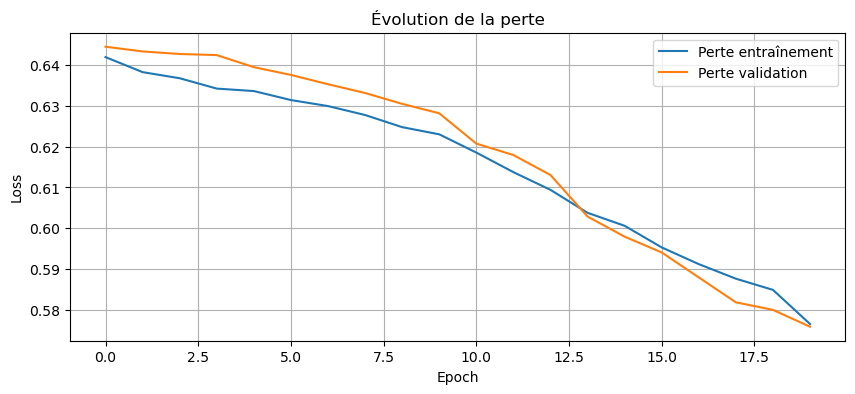

<Figure size 640x480 with 0 Axes>

In [45]:

# =============================
# 10. Afficher courbe de perte
# =============================
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Perte entraînement')
plt.plot(history.history['val_loss'], label='Perte validation')
plt.title("Évolution de la perte")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()


# Enregistrement en PNG
plt.savefig("courbe_perte_lstm3.png", dpi=300)  # dpi=300 pour une meilleure qualité

In [53]:
# 1. Prédictions brutes (probabilités) et classes
y_proba = model.predict(X_test).flatten()
y_pred = (y_proba > 0.5).astype(int)

# 2. Classification Metrics
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 3. Erreurs (sur probabilités ou classes)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # ou y_proba
msae = mean_absolute_error(y_test, y_pred)

# 4. Affichage
print("\n📈 Métriques de performance :")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"MSAE (MAE)   : {msae:.4f}")

140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

📈 Métriques de performance :
Recall       : 0.9901
Precision    : 0.6637
F1-score     : 0.7947
RMSE         : 0.5793
MSAE (MAE)   : 0.3356


In [32]:
print(df['panne'].value_counts())


panne
1    99528
0      472
Name: count, dtype: int64


In [58]:
# =============================
# 7. Modèle 2  LSTM
# =============================
# Fixer les seeds pour la reproductibilité
seed_value = 42

os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(LSTM(64, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entraînement avec early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    class_weight={0: 1, 1: 3}  # Ajustable
)

y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.7).astype(int)

print(classification_report(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_proba)))

Epoch 1/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - accuracy: 0.6682 - loss: 0.9895 - val_accuracy: 0.6559 - val_loss: 0.7723
Epoch 2/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6693 - loss: 0.9592 - val_accuracy: 0.6559 - val_loss: 0.7919
Epoch 3/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6693 - loss: 0.9539 - val_accuracy: 0.6559 - val_loss: 0.7388
Epoch 4/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6695 - loss: 0.9495 - val_accuracy: 0.6559 - val_loss: 0.7811
Epoch 5/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6698 - loss: 0.9466 - val_accuracy: 0.6559 - val_loss: 0.7515
Epoch 6/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6700 - loss: 0.9447 - val_accuracy: 0.6586 - val_loss: 0.7710
Epoch 7/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.6726 - loss: 0.9389 - val_accuracy: 0.6575 - val_loss: 0.7602
Epoch 8/30
280/280 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6742 - loss: 0.9294 - val_accu

In [59]:
# 1. Prédictions brutes (probabilités) et classes
y_proba = model.predict(X_test).flatten()
y_pred = (y_proba > 0.5).astype(int)

# 2. Classification Metrics
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 3. Erreurs (sur probabilités ou classes)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # ou y_proba
msae = mean_absolute_error(y_test, y_pred)

# 4. Affichage
print("\n📈 Métriques de performance :")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"MSAE (MAE)   : {msae:.4f}")

140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step 

📈 Métriques de performance :
Recall       : 0.9452
Precision    : 0.9911
F1-score     : 0.9676
RMSE         : 0.2039
MSAE (MAE)   : 0.0416


In [69]:

# Fixer les seeds pour la reproductibilité
seed_value = 42
os.environ['PYTHONHASHSEED'] = str(seed_value)
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

# Modèle GRU-LSTM
model = Sequential()
model.add(Input(shape=(X_train.shape[1], X_train.shape[2])))
model.add(GRU(64, return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Entraînement
model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=64,
    callbacks=[early_stop],
    class_weight={0: 1, 1: 3}
)

# Prédiction et métriques
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.7).astype(int)

print(classification_report(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_proba)))

Epoch 1/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.6689 - loss: 0.9883 - val_accuracy: 0.6559 - val_loss: 0.7895
Epoch 2/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6693 - loss: 0.9608 - val_accuracy: 0.6559 - val_loss: 0.7894
Epoch 3/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6693 - loss: 0.9535 - val_accuracy: 0.6559 - val_loss: 0.7816
Epoch 4/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6702 - loss: 0.9485 - val_accuracy: 0.6559 - val_loss: 0.7794
Epoch 5/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.6716 - loss: 0.9377 - val_accuracy: 0.6586 - val_loss: 0.7716
Epoch 6/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.6742 - loss: 0.9206 - val_accuracy: 0.6586 - val_loss: 0.7517
Epoch 7/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.6757 - loss: 0.9055 - val_accuracy: 0.6586 - val_loss: 0.7383
Epoch 8/20
280/280 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6769 - loss: 0.8858 - val_a

In [70]:
# 1. Prédictions brutes (probabilités) et classes
y_proba = model.predict(X_test).flatten()
y_pred = (y_proba > 0.5).astype(int)

# 2. Classification Metrics
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 3. Erreurs (sur probabilités ou classes)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # ou y_proba
msae = mean_absolute_error(y_test, y_pred)

# 4. Affichage
print("\n📈 Métriques de performance :")
print(f"Recall       : {recall:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"F1-score     : {f1:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"MSAE (MAE)   : {msae:.4f}")

140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step 

📈 Métriques de performance :
Recall       : 0.9792
Precision    : 1.0000
F1-score     : 0.9895
RMSE         : 0.1167
MSAE (MAE)   : 0.0136


In [ ]:
# Compter les occurrences par état
state_counts = df['State_ISO'].value_counts().sort_index()

# Affichage
plt.figure(figsize=(8, 5))
state_counts.plot(kind='bar', color=['green', 'orange', 'red', 'darkred'])
plt.title("Répartition des états ISO de vibration")
plt.xlabel("État ISO")
plt.ylabel("Nombre d'occurrences")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

560/560 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


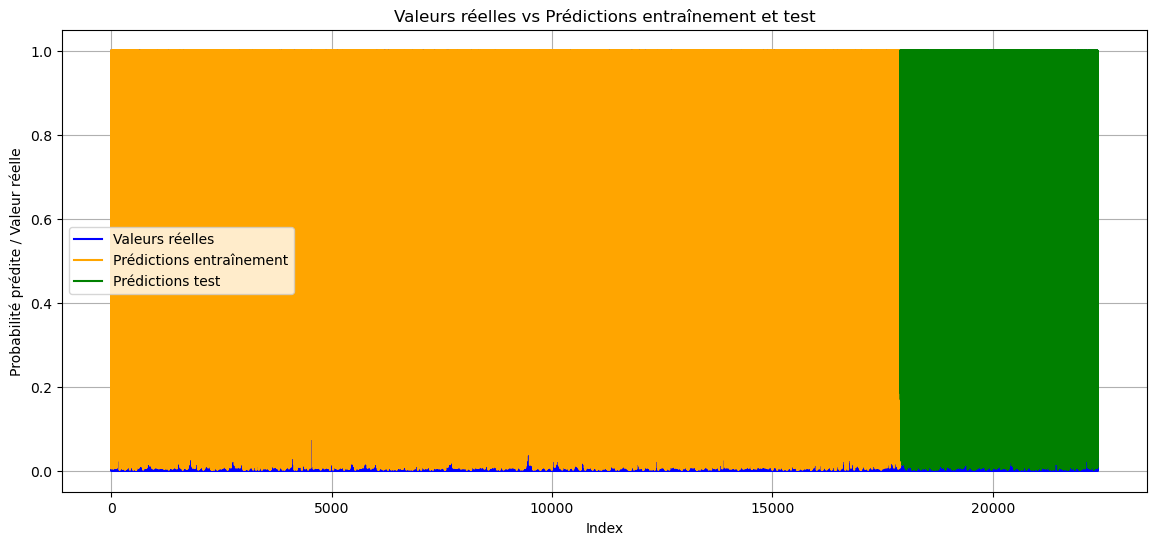

In [75]:
# Prédictions sur train (en probabilités)
y_train_pred_proba = model.predict(X_train)

# On peut aussi transformer en labels binaires si besoin
# y_train_pred = (y_train_pred_proba > 0.7).astype(int)

# Préparer un vecteur complet pour la vraie valeur + prédictions pour la visualisation
# On concatène train + test

y_true = np.concatenate([y_train, y_test])
y_pred_proba_full = np.concatenate([y_train_pred_proba, y_pred_proba])

plt.figure(figsize=(14,6))
plt.plot(y_true, label='Valeurs réelles', color='blue')
plt.plot(np.arange(len(y_train_pred_proba)), y_train_pred_proba, label='Prédictions entraînement', color='orange')
plt.plot(np.arange(len(y_train_pred_proba), len(y_train_pred_proba)+len(y_pred_proba)), y_pred_proba, label='Prédictions test', color='green')
plt.title('Valeurs réelles vs Prédictions entraînement et test')
plt.xlabel('Index')
plt.ylabel('Probabilité prédite / Valeur réelle')
plt.legend()
plt.grid()
plt.show()